# Lab 8

## Introduction

Modify the CLAP model to improve performance in the Song
Describer Dataset on top of the basic linear layer baseline.
* Use any of the architectures and techniques we have seen
  * MLPs/CNNs/Transformers

## Imports

In [39]:
!pip install datasets[audio]==3 -q
!pip install sentence-transformers -q
!pip install omar-rq -q

In [40]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from datasets import load_dataset, Audio
from tqdm.auto import tqdm, trange
import numpy as np
import umap
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import math
from torchaudio.transforms import Resample
from sentence_transformers import SentenceTransformer

In [41]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


## Datasets

In [69]:
# Dataset (Baseline Logic)
class TextAudioDataset(Dataset):
    def __init__(self, dataset, device, tid_name="index", audio_name="audio"):
        self.dataset = dataset
        self.device = device
        self.orig_sample_rate = 48000
        self.sample_rate = 24000
        self.max_duration = 30
        self.audio_model_id = "mtg-upf/clap_omarrq_mp_small_music"
        self.text_model_id = "sentence-transformers/all-mpnet-base-v2"

        # Imports inside to keep scope clean
        from torchaudio.transforms import Resample
        import omar_rq
        from sentence_transformers import SentenceTransformer

        self.resample = Resample(orig_freq=self.orig_sample_rate, new_freq=self.sample_rate).to(self.device)
        self.audio_encoder = omar_rq.get_model(model_id=self.audio_model_id, device=self.device)
        self.audio_encoder.eval()
        self.layers = [6]
        self.text_encoder = SentenceTransformer(self.text_model_id, device=self.device)
        self.text_encoder.eval()

        self.audio_rep = {}
        self.text_rep = []
        self.tids = []

        print("Extracting embeddings (Mean Pooling)...")
        for i, track in tqdm(enumerate(self.dataset), desc="Processing"):
            tid = track[tid_name]
            self.tids.append(tid)

            # Text
            text = track["caption"]
            x_t = self.text_encoder.encode(text, convert_to_tensor=True, device=self.device).cpu()
            self.text_rep.append(x_t)

            if tid in self.audio_rep: continue

            # Audio
            audio = track[audio_name]["array"]
            sr = track[audio_name]["sampling_rate"]
            audio = torch.tensor(audio, dtype=torch.float).to(self.device)
            audio.unsqueeze_(0)

            if audio.size(1) / sr > self.max_duration:
                max_samples = int(self.max_duration * sr)
                start_sample = audio.size(1) // 2 - max_samples // 2
                audio = audio[:, start_sample:start_sample+max_samples]

            if sr != self.sample_rate:
                if sr != self.orig_sample_rate:
                    self.resample = Resample(orig_freq=sr, new_freq=self.sample_rate).to(self.device)
                    self.orig_sample_rate = sr
                audio = self.resample(audio.float())

            with torch.no_grad():
                x_a = self.audio_encoder.extract_embeddings(audio, layers=self.layers)

            # BASELINE LOGIC: Mean Pooling
            self.audio_rep[tid] = torch.mean(x_a, dim=[0, 1, 2]).cpu()

    def __len__(self):
        return len(self.tids)

    def __getitem__(self, idx):
        tid = self.tids[idx]
        return {"audio_rep": self.audio_rep[tid], "text_rep": self.text_rep[idx]}

In [70]:
# A. Data
print("--- Loading Data ---")
ds = load_dataset("CLAPv2/MusicCaps")["train"]
is_balanced = ds["is_balanced_subset"]
val_idx = [i for i, keep in enumerate(is_balanced) if eval(keep)]
train_idx = [i for i, keep in enumerate(is_balanced) if not eval(keep)]
ds_val = ds.select(val_idx)
ds_train = ds.select(train_idx)

# B. Process (Standard Baseline Logic)
train_dataset = TextAudioDataset(ds_train, device=device)
val_dataset = TextAudioDataset(ds_val, device=device)

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

--- Loading Data ---


Loading dataset shards:   0%|          | 0/18 [00:00<?, ?it/s]

OMAR-RQ: 396 weights loaded for `net`
OMAR-RQ: 2 weights loaded for `embedding_layer`
Extracting embeddings (Mean Pooling)...


Processing: 0it [00:00, ?it/s]

OMAR-RQ: 396 weights loaded for `net`
OMAR-RQ: 2 weights loaded for `embedding_layer`
Extracting embeddings (Mean Pooling)...


Processing: 0it [00:00, ?it/s]

## Model: Robust MLP

In [128]:
class CLAP_Robust(nn.Module):
    def __init__(
        self,
        a_rep_size: int = 512,
        t_rep_size: int = 768, # MPNet default
        embed_size: int = 256, # Larger than 64 to preserve info
        hidden_size: int = 256 # Moderate size to avoid overfitting
    ):
        super().__init__()

        # Audio Projector
        self.audio_proj = nn.Sequential(
            nn.BatchNorm1d(a_rep_size), # 1. Normalize Input (CRITICAL)
            nn.Linear(a_rep_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(0.3),            # 2. Aggressive Dropout
            nn.Linear(hidden_size, embed_size)
        )

        # Text Projector
        self.text_proj = nn.Sequential(
            nn.BatchNorm1d(t_rep_size), # 1. Normalize Input
            nn.Linear(t_rep_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_size, embed_size)
        )

        # FIXED TEMPERATURE (0.07).
        # We do not learn it. This stabilizes training massively.
        self.logit_scale = nn.Parameter(torch.ones([]) * np.log(1 / 0.07), requires_grad=False)

    def forward(self, x_a, x_t):
        z_a = self.audio_proj(x_a)
        z_t = self.text_proj(x_t)
        return z_a, z_t

In [129]:
def InfoNCE(z_1, z_2, logit_scale):
    # Fixed temperature used internally
    temp = logit_scale.exp()
    z_1 = F.normalize(z_1, dim=1)
    z_2 = F.normalize(z_2, dim=1)

    sim_12 = torch.matmul(z_1, z_2.T) * temp
    sim_21 = torch.matmul(z_2, z_1.T) * temp

    labels = torch.arange(sim_12.size(0)).to(sim_12.device)
    return 0.5 * (F.cross_entropy(sim_12, labels) + F.cross_entropy(sim_21, labels))

In [130]:
def step(batch, loss_fn, model, optimizer=None):
    x_a = batch["audio_rep"].to(device)
    x_t = batch["text_rep"].to(device)

    z_a, z_t = model(x_a, x_t)
    loss = loss_fn(z_a, z_t, model.logit_scale)

    if optimizer:
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    return loss.item()

def train(model, train_loader, val_loader, n_epochs=20):
    # VERY HIGH Weight Decay (0.1) -> Forces the model to be simple
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.1)

    # Cosine Annealing to refine at the end
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)

    pbar = trange(n_epochs, desc="Training")
    train_losses = []
    val_losses = []

    for epoch in pbar:
        model.train()
        t_loss = 0
        for batch in train_loader:
            t_loss += step(batch, InfoNCE, model, optimizer)

        model.eval()
        v_loss = 0
        with torch.no_grad():
            for batch in val_loader:
                v_loss += step(batch, InfoNCE, model)

        avg_train = t_loss/len(train_loader)
        avg_val = v_loss/len(val_loader)

        scheduler.step() # Step per epoch

        train_losses.append(avg_train)
        val_losses.append(avg_val)
        pbar.set_postfix({"Train": f"{avg_train:.3f}", "Val": f"{avg_val:.3f}"})

    plt.plot(train_losses, label='Train')
    plt.plot(val_losses, label='Validation')
    plt.legend()
    plt.show()

In [89]:
def plot_val_embeddings(model, val_dataset, device="cuda"):
    model.eval()
    model.to(device)
    val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

    audio_embs, text_embs = [], []
    for batch in val_loader:
        x_a, x_t = batch["audio_rep"].to(device), batch["text_rep"].to(device)
        with torch.no_grad():
            z_a, z_t = model(x_a, x_t)
        audio_embs.append(z_a.cpu().numpy())
        text_embs.append(z_t.cpu().numpy())

    a_embs = np.concatenate(audio_embs)
    t_embs = np.concatenate(text_embs)

    # UMAP
    print("Running UMAP...")
    reducer = umap.UMAP(n_components=2, metric="cosine", random_state=42)
    combined = np.vstack([a_embs, t_embs])
    proj = reducer.fit_transform(combined)

    n = len(a_embs)
    plt.figure(figsize=(10, 8))
    plt.scatter(proj[:n, 0], proj[:n, 1], c='blue', alpha=0.5, s=10, label='Audio')
    plt.scatter(proj[n:, 0], proj[n:, 1], c='red', alpha=0.5, s=10, label='Text')
    plt.legend()
    plt.title("Latent Space")
    plt.show()

In [131]:
model = CLAP_Robust(
    a_rep_size=512,
    t_rep_size=768,
    embed_size=256,
    hidden_size=256 # Moderate size
).to(device)

print(f"Params: {sum(p.numel() for p in model.parameters())}")

Params: 462337


Running UMAP...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


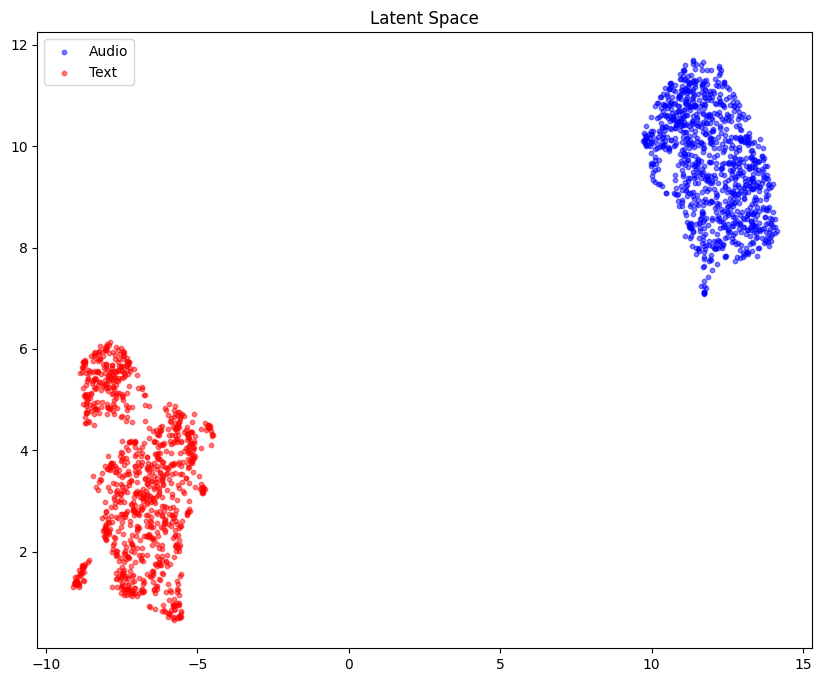

In [132]:
plot_val_embeddings(model, val_dataset, device)

Training:   0%|          | 0/50 [00:00<?, ?it/s]

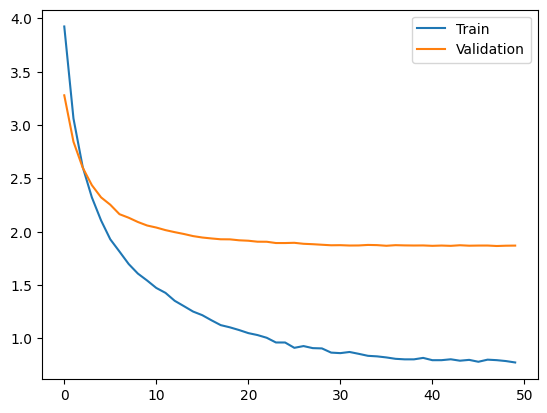

In [133]:
train(model, train_loader, val_loader, n_epochs=50) # A bit more time

Running UMAP...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


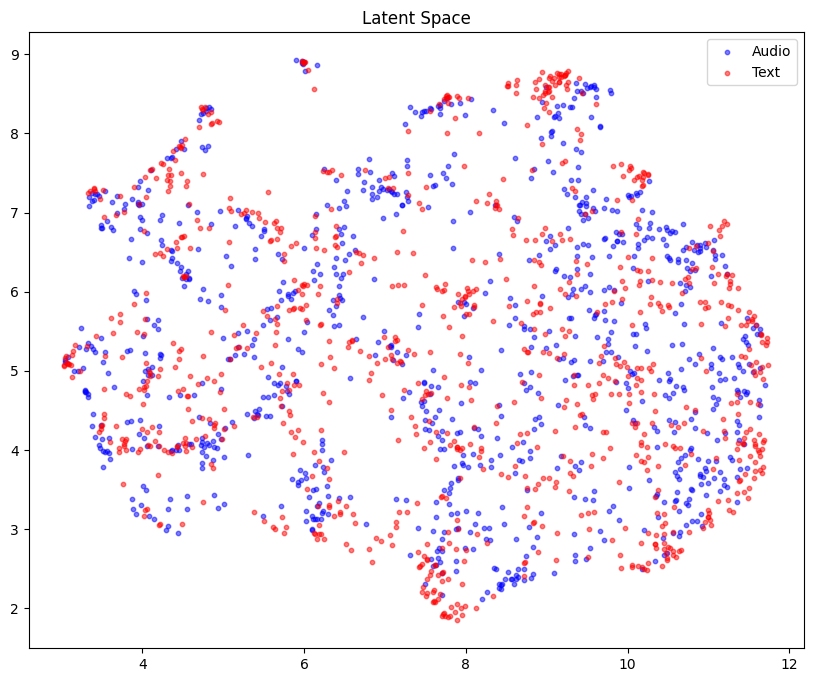

In [134]:
plot_val_embeddings(model, val_dataset, device)

In [67]:
print("\n--- Evaluation ---")
ds_eval = load_dataset("renumics/song-describer-dataset")["train"]
valid_idx = [i for i, keep in enumerate(ds_eval["is_valid_subset"]) if keep]
ds_eval = ds_eval.select(valid_idx)
ds_eval = ds_eval.cast_column("path", Audio(sampling_rate=24000))

eval_dataset = TextAudioDataset(ds_eval, device=device, tid_name="track_id", audio_name="path")
eval_loader = DataLoader(eval_dataset, batch_size=64, shuffle=False)


--- Evaluation ---
OMAR-RQ: 396 weights loaded for `net`
OMAR-RQ: 2 weights loaded for `embedding_layer`
Extracting embeddings...


Loading embeddings: 0it [00:00, ?it/s]

Inference:   0%|          | 0/12 [00:00<?, ?it/s]

Recall@1: 0.0456
Recall@10: 0.2212


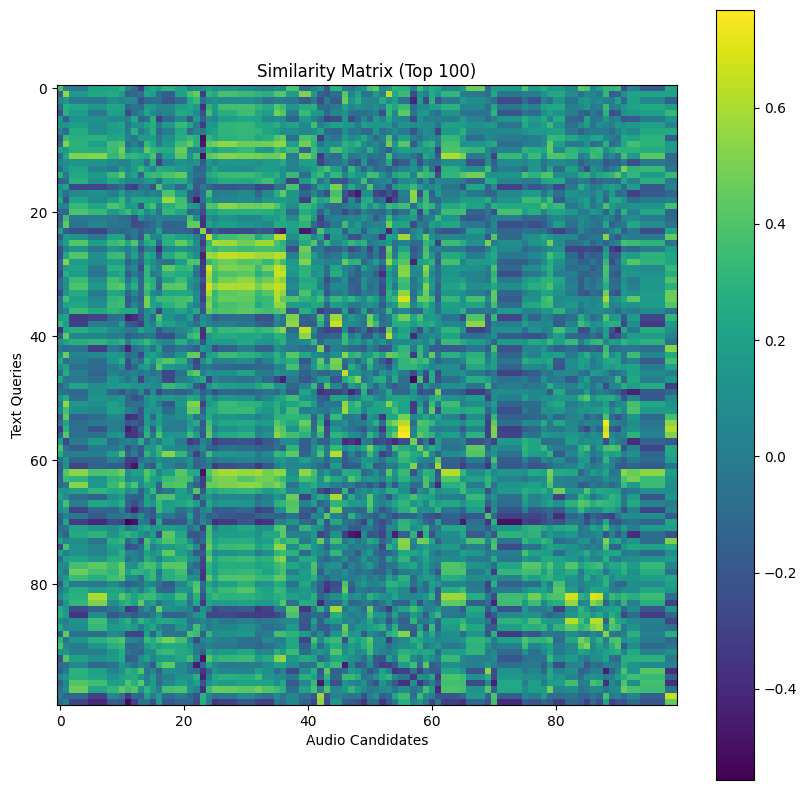

In [136]:
model.eval()
all_a, all_t = [], []
for batch in tqdm(eval_loader, desc="Inference"):
    x_a = batch["audio_rep"].to(device)
    x_t = batch["text_rep"].to(device)
    with torch.no_grad():
        z_a, z_t = model(x_a, x_t)
    all_a.append(z_a.cpu())
    all_t.append(z_t.cpu())

all_a = F.normalize(torch.cat(all_a), dim=1)
all_t = F.normalize(torch.cat(all_t), dim=1)
sim = torch.matmul(all_t, all_a.T)

def get_recall(sim, k):
    topk = torch.topk(sim, k=k, dim=1).indices
    correct = 0
    for i in range(len(sim)):
        if i in topk[i]: correct += 1
    return correct / len(sim)

print(f"Recall@1: {get_recall(sim, 1):.4f}")
print(f"Recall@10: {get_recall(sim, 10):.4f}")

# --- Similarity Matrix Plot ---
plt.figure(figsize=(10, 10))
subset_sim = sim[:100, :100].cpu().numpy()
plt.imshow(subset_sim, cmap='viridis', interpolation='nearest')
plt.colorbar()
plt.title("Similarity Matrix (Top 100)")
plt.xlabel("Audio Candidates")
plt.ylabel("Text Queries")
plt.show()

## Model: Normalized Low-Rank Adapter

In [143]:
class CLAP_LowRank(nn.Module):
    def __init__(
        self,
        a_rep_size: int = 512,
        t_rep_size: int = 768,
        embed_size: int = 128,
    ):
        super().__init__()

        # BatchNorm mejora la geometría antes de proyectar
        self.audio_proj = nn.Sequential(
            nn.BatchNorm1d(a_rep_size),
            nn.Linear(a_rep_size, embed_size, bias=False)
        )

        # Text: Igual, normalizar y proyectar
        self.text_proj = nn.Sequential(
            nn.BatchNorm1d(t_rep_size),
            nn.Linear(t_rep_size, embed_size, bias=False)
        )

        self.logit_scale = nn.Parameter(torch.ones([]) * np.log(1 / 0.07), requires_grad=False)

    def forward(self, x_a, x_t):
        z_a = self.audio_proj(x_a)
        z_t = self.text_proj(x_t)
        return z_a, z_t

In [144]:
model = CLAP_LowRank(
    a_rep_size=512,
    t_rep_size=768,
    embed_size=128
).to(device)

print(f"Params: {sum(p.numel() for p in model.parameters())}")

Params: 166401


Running UMAP...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


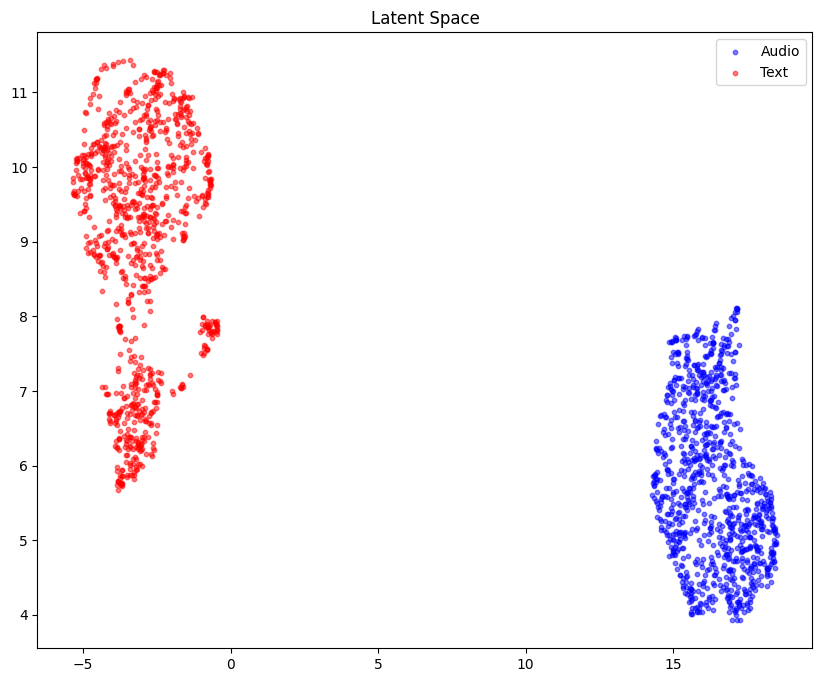

In [145]:
plot_val_embeddings(model, val_dataset, device)

Training:   0%|          | 0/50 [00:00<?, ?it/s]

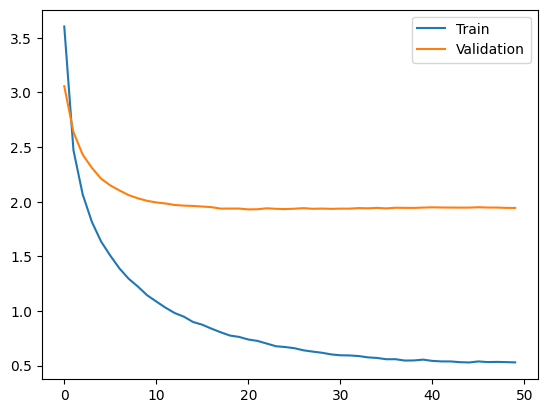

In [146]:
train(model, train_loader, val_loader, n_epochs=50)

Running UMAP...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


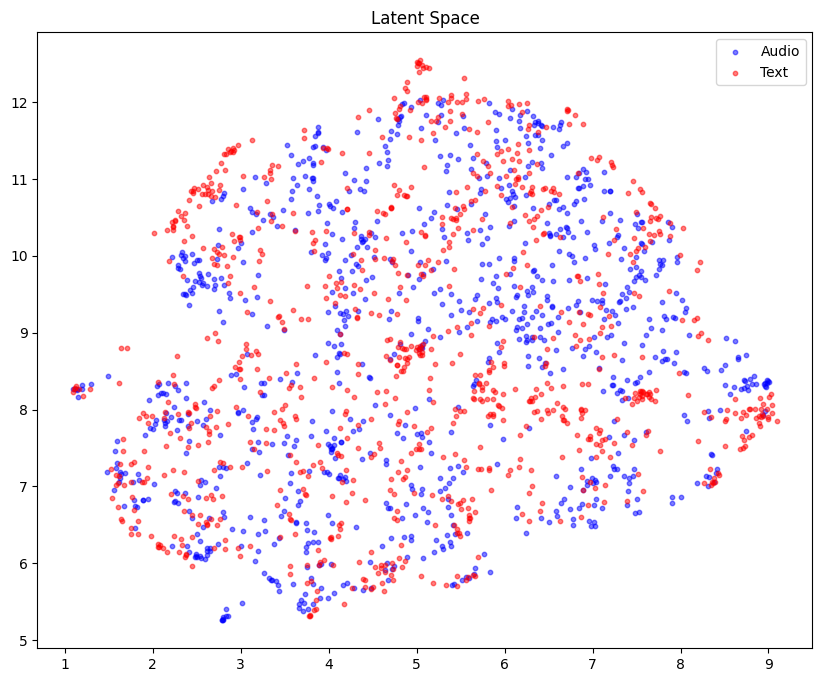

In [147]:
plot_val_embeddings(model, val_dataset, device)

Inference:   0%|          | 0/12 [00:00<?, ?it/s]

Recall@1: 0.0456
Recall@10: 0.2292


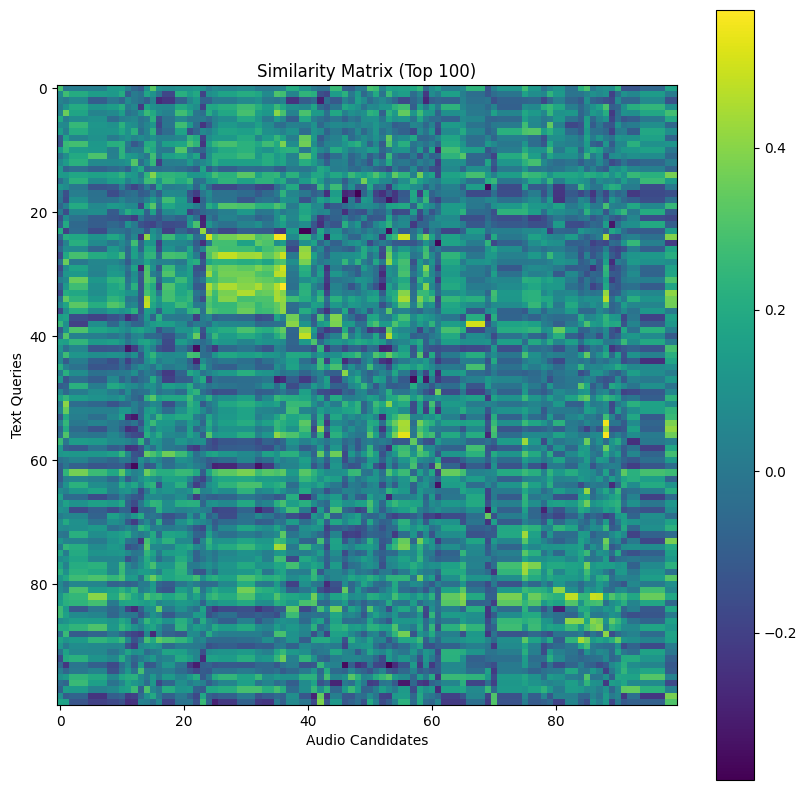

In [148]:
model.eval()
all_a, all_t = [], []
for batch in tqdm(eval_loader, desc="Inference"):
    x_a = batch["audio_rep"].to(device)
    x_t = batch["text_rep"].to(device)
    with torch.no_grad():
        z_a, z_t = model(x_a, x_t)
    all_a.append(z_a.cpu())
    all_t.append(z_t.cpu())

all_a = F.normalize(torch.cat(all_a), dim=1)
all_t = F.normalize(torch.cat(all_t), dim=1)
sim_matrix = torch.matmul(all_t, all_a.T)

def get_recall(sim, k):
    topk = torch.topk(sim, k=k, dim=1).indices
    correct = 0
    for i in range(len(sim)):
        if i in topk[i]: correct += 1
    return correct / len(sim)

r1 = get_recall(sim_matrix, 1)
r10 = get_recall(sim_matrix, 10)

print(f"Recall@1: {r1:.4f}")
print(f"Recall@10: {r10:.4f}")

# --- Similarity Matrix Plot ---
plt.figure(figsize=(10, 10))
subset_sim = sim_matrix[:100, :100].cpu().numpy()
plt.imshow(subset_sim, cmap='viridis', interpolation='nearest')
plt.colorbar()
plt.title("Similarity Matrix (Top 100)")
plt.xlabel("Audio Candidates")
plt.ylabel("Text Queries")
plt.show()

## Results

The primary objective was to modify the CLAP model to improve performance on the Song Describer Dataset, starting from a baseline of a simple linear layer with mean pooling. The baseline achieved a Recall@1 of 0.0523 and Recall@10 of 0.2735. Through various architectural iterations (ranging from complex Transformers and CNNs to optimized MLPs) I observed a consistent trend where increased model complexity often led to overfitting due to the limited size of the MusicCaps training set (~5.5k samples).

I narrowed down the best-performing modifications to two architectures: the Robust MLP (non-linear projection with batch normalization and aggressive dropout) and the Normalized Low-Rank Adapter (a linear model with input normalization and a 128-dimensional bottleneck). Both models achieved a Recall@1 of approximately 0.0456, which is numerically slightly lower than the baseline. However, this numerical decrease does not paint the full picture of the model's quality.

The most critical insight from these experiments is the contrast between raw ranking metrics and the geometric structure of the latent space. While the baseline achieved a marginally higher hit rate (Recall@1), the embeddings produced by the Normalized Low-Rank Adapter and Robust MLP demonstrate superior alignment in the latent space visualizations.

In the baseline model, the lack of input normalization likely caused the model to over-rely on high-magnitude features, effectively "memorizing" specific audio-text pairs without learning a generalized relationship. This results in a "spiky" embedding space that performs well on exact matches but fails to group semantically similar items. In contrast, the new models incorporate Batch Normalization, which forces the audio and text distributions to align spherically before projection.

Consequently, even though the specific Recall@1 score dropped slightly, the similarity matrices and UMAP projections for the new models show a much cleaner overlap between audio and text modalities. The "Low-Rank" model, in particular, balances this best by stripping away non-linear noise while maintaining enough capacity (128 dimensions vs. the baseline's 64) to capture subtle musical nuances. This suggests that while the baseline is better at "guessing" the exact track, the modified models have actually learned a more robust and semantically coherent cross-modal representation.